In [67]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from model_evaluation import *
from model_training import *
import ft_engineering
import pandas as pd
import numpy as np
from cargar_datos import *
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
%load_ext autoreload
%autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Carga de datos

In [48]:
df = cargarDatos()
df.sample(5)

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
1441,9,2025-04-19 11:36:24,1382756.4,7,62,Empleado,4500000,3000000,163360,95.227787,...,0.0,306867.0,306867.0,0.0,3,1,0,NaN,NaN,1
3462,4,2025-01-19 16:12:02,1436400.0,24,48,Empleado,1000000,600000,63131,95.227787,...,0.0,0.0,0.0,0.0,3,0,0,1197944.0,Creciente,1
6406,4,2024-12-02 13:16:30,6676800.0,6,43,Independiente,6000000,3000000,988295,95.227787,...,0.0,17581.0,17581.0,0.0,2,0,2,904137.0,Creciente,1
5450,4,2025-02-27 17:28:13,1917600.0,6,51,Independiente,7000000,3500000,284816,95.227787,...,0.0,12023.0,12023.0,0.0,3,1,1,903132.0,Creciente,1
6977,9,2025-08-15 17:09:28,4720542.0,9,39,Independiente,908526,615000,443393,95.227787,...,0.0,19130.0,19130.0,0.0,0,1,1,733487.0,Creciente,1


#### Overfit generado por data leakage

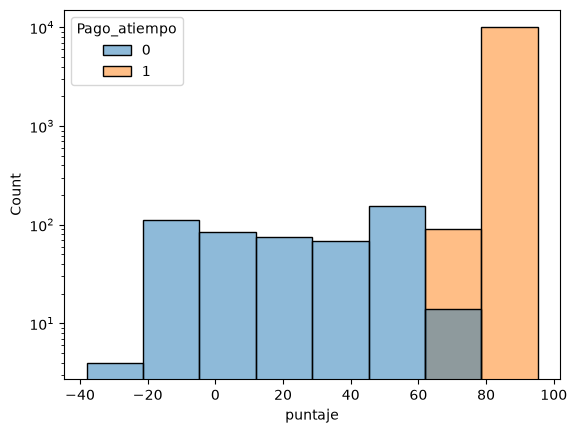

In [40]:
import seaborn as sns
sns.histplot(df, x='puntaje', hue='Pago_atiempo', bins=8)
plt.yscale('log')
plt.show()

## Transformacion (Columnas con error)

In [49]:
df = ft_engineering.limpiar_categoricas_con_ruido_numerico(df, 'tendencia_ingresos',['Creciente','Decreciente','Estable'] )
df['tendencia_ingresos'].value_counts()

tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
Name: count, dtype: int64

In [50]:
num, cat, ord = ft_engineering._get_feature_columns(df)

In [51]:
preprocessor = ft_engineering.build_preprocessor(num, cat, ord)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per t

In [52]:
X = df.drop(columns=["Pago_atiempo", EXCLUIR_DE_X[0]])
y = df["Pago_atiempo"]

# 4 ajustar el preprocesador
X_processed = preprocessor.fit_transform(X)

In [54]:
X_processed = pd.DataFrame(
    X_processed,
    columns=preprocessor.get_feature_names_out()
)
X_processed.sample(5)

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,...,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tipo_laboral_Independiente,tendencia_ingresos_Decreciente,tendencia_ingresos_Estable,tipo_credito
1806,587520.0,6.0,26.0,2410000.0,0.0,88851.0,788.0,8.0,7.0,0.0,...,2309.0,0.0,1.0,0.0,3.0,1204496.0,0.0,0.0,0.0,0.0
2870,8640000.0,36.0,69.0,6200000.0,1000000.0,279360.0,921.0,5.0,3.0,0.0,...,9642.0,0.0,5.0,0.0,0.0,7200850.0,0.0,0.0,0.0,0.0
502,5543917.2,36.0,54.0,4300000.0,807000.0,199172.0,853.0,3.0,1.0,0.0,...,47096.0,0.0,2.0,0.0,1.0,5960882.0,0.0,0.0,0.0,0.0
5753,1892100.0,6.0,38.0,2400000.0,920000.0,280826.0,739.0,3.0,3.0,0.0,...,5162.0,0.0,1.0,0.0,2.0,2040766.0,0.0,1.0,0.0,0.0
7521,2099640.0,6.0,31.0,3000000.0,600000.0,314478.0,712.0,3.0,5.0,0.0,...,1824.0,0.0,1.0,0.0,1.0,1204496.0,0.0,0.0,0.0,0.0


In [55]:
dataset_model = X_processed.copy()
dataset_model['Pago_atiempo'] = y
dataset_model.sample(8)

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,...,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tipo_laboral_Independiente,tendencia_ingresos_Decreciente,tendencia_ingresos_Estable,tipo_credito,Pago_atiempo
2114,2439634.8,10.0,43.0,3500000.0,1111110.0,206919.0,675.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1204496.0,1.0,0.0,0.0,3.0,1
10610,1269000.0,2.0,27.0,5000000.0,2000000.0,500798.0,729.0,10.0,6.0,0.0,...,0.0,4.0,2.0,2.0,954263.0,1.0,0.0,0.0,3.0,1
597,2241819.6,9.0,43.0,8000000.0,5000000.0,209367.0,821.0,5.0,0.0,0.0,...,0.0,1.0,0.0,2.0,2436742.0,0.0,0.0,0.0,3.0,1
6540,918705.6,8.0,54.0,1500000.0,500000.0,95736.0,835.0,4.0,3.0,0.0,...,0.0,1.0,1.0,1.0,1457323.0,0.0,0.0,0.0,3.0,1
6881,2708928.0,9.0,48.0,1500000.0,800000.0,256598.0,805.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,911561.0,1.0,0.0,0.0,3.0,1
4815,4200000.0,6.0,39.0,20000000.0,1000000.0,623365.0,803.0,10.0,7.0,0.0,...,0.0,6.0,0.0,2.0,1227272.0,1.0,1.0,0.0,0.0,1
10045,2563078.8,12.0,23.0,1600000.0,300000.0,201102.0,814.0,5.0,1.0,0.0,...,0.0,1.0,0.0,2.0,1697342.0,0.0,0.0,0.0,0.0,1
2862,1753440.0,6.0,63.0,1626000.0,0.0,259958.0,751.0,5.0,4.0,0.0,...,0.0,1.0,0.0,1.0,1204496.0,1.0,0.0,0.0,0.0,1


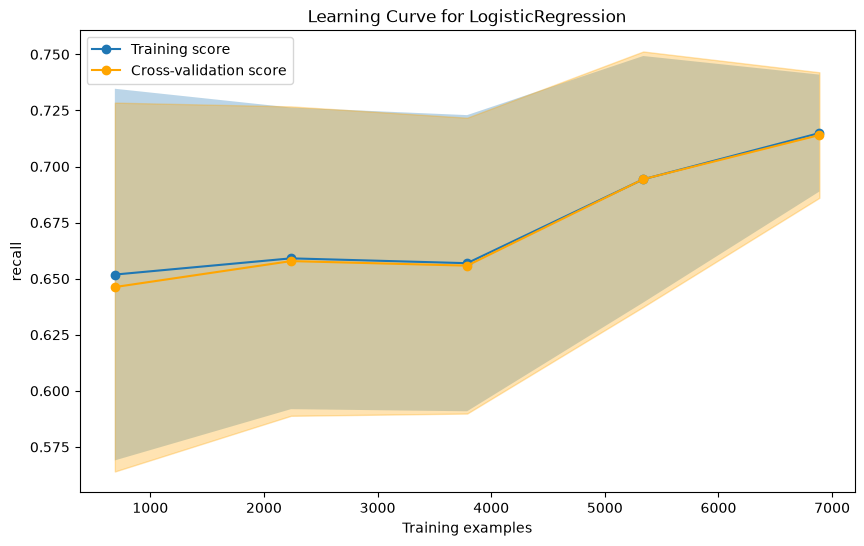

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [0.65183249 0.65906475 0.65690763 0.69430067 0.71490144]
Training Scores Std: [0.08283079 0.06722225 0.06600381 0.05495078 0.02605802]
Test Scores Mean: [0.64626622 0.6578424  0.65581031 0.69434273 0.71402243]
Test Scores Std: [0.08220623 0.06895464 0.06592646 0.0569217  0.02797438]


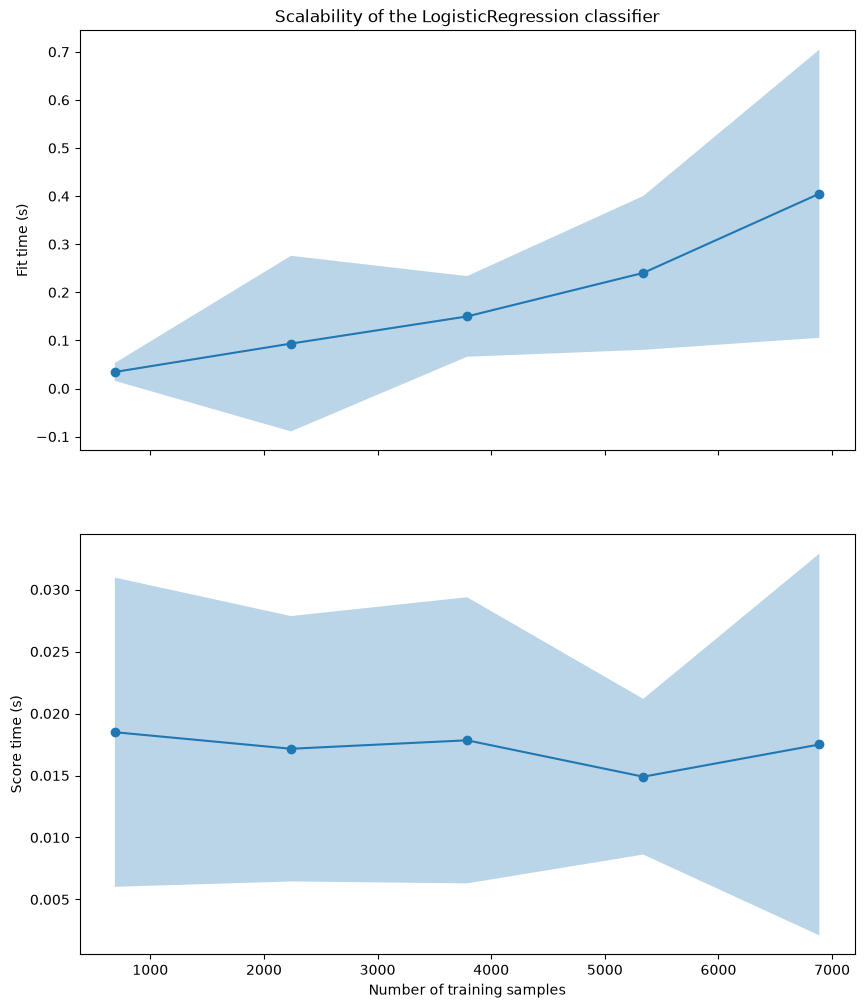

Fit Times Mean: [0.03441331 0.09340614 0.14986471 0.24036333 0.4050696 ]
Fit Times Std: [0.01853388 0.18257498 0.08381651 0.15995473 0.29958629]
Score Times Mean: [0.01849213 0.01715729 0.01783985 0.0149034  0.01750106]
Score Times Std: [0.01247265 0.01070496 0.01153975 0.00628084 0.01539917]


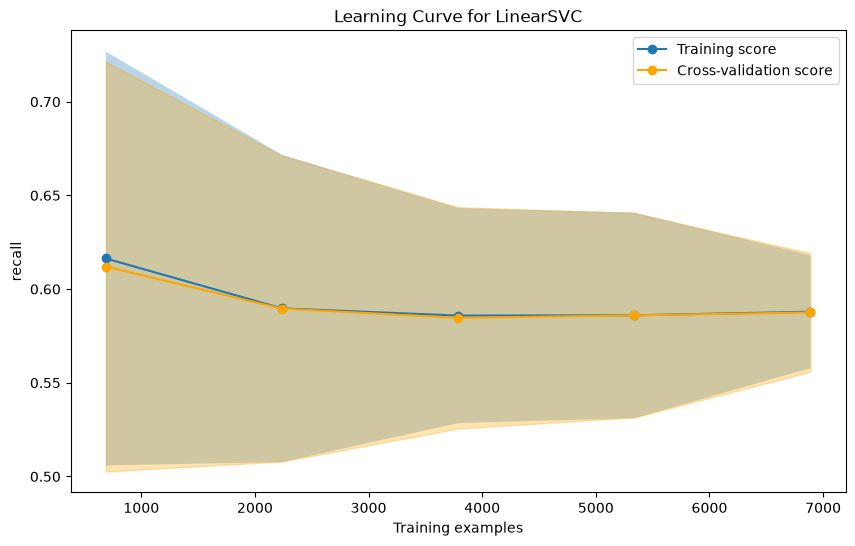

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [0.61633315 0.58970846 0.58585452 0.58602403 0.58791918]
Training Scores Std: [0.11044999 0.08199701 0.05737507 0.05487059 0.03014291]
Test Scores Mean: [0.61200945 0.5895925  0.58466009 0.58598005 0.58755157]
Test Scores Std: [0.10934925 0.08159381 0.05906121 0.05450451 0.03159068]


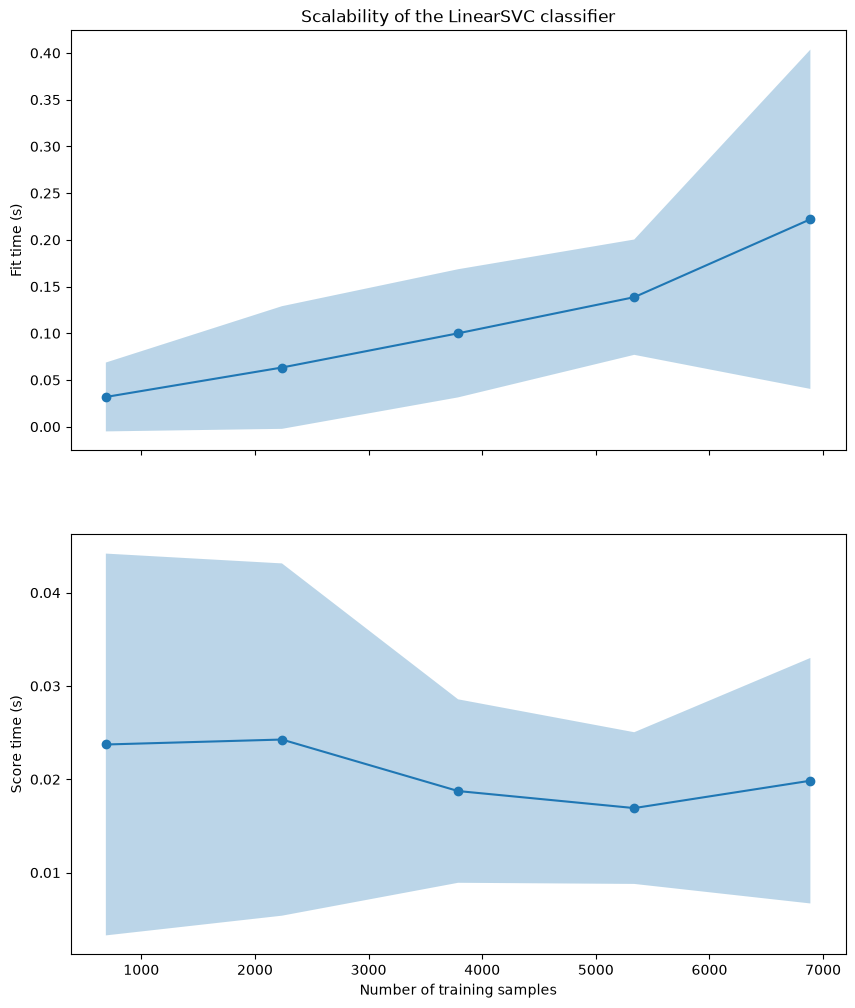

Fit Times Mean: [0.03183999 0.063368   0.09998016 0.13864867 0.2220364 ]
Fit Times Std: [0.03684989 0.06564274 0.06857616 0.06171076 0.18158218]
Score Times Mean: [0.02373054 0.02426157 0.01874096 0.01691631 0.0198498 ]
Score Times Std: [0.02046091 0.01887818 0.00983163 0.00812926 0.01315683]


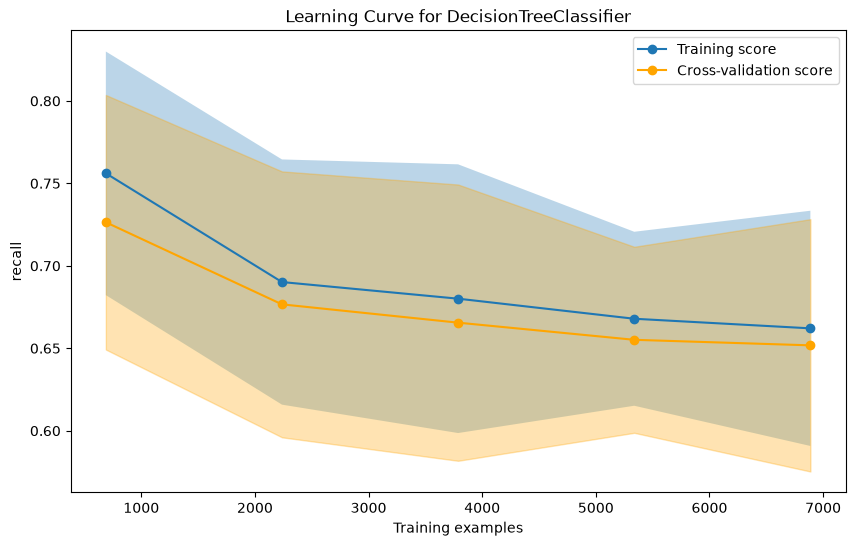

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [0.75610532 0.69016312 0.68007973 0.66791135 0.66208939]
Training Scores Std: [0.0738562  0.07434408 0.08146818 0.05274276 0.07132185]
Test Scores Mean: [0.726412   0.67663281 0.66553764 0.6551401  0.65178482]
Test Scores Std: [0.0771663  0.08061113 0.08375058 0.05639475 0.07649531]


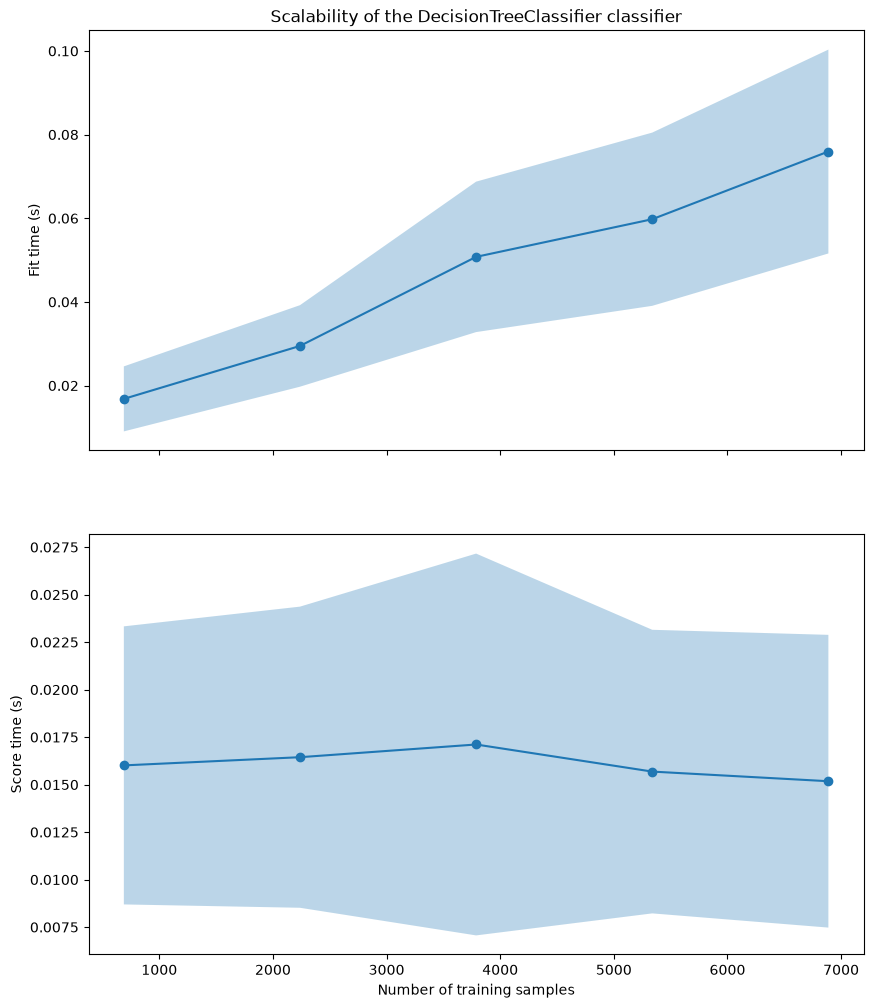

Fit Times Mean: [0.01681752 0.02947728 0.05077281 0.0597737  0.07595553]
Fit Times Std: [0.00777138 0.00974603 0.01798389 0.02070786 0.02436884]
Score Times Mean: [0.01601202 0.01644338 0.01711201 0.01568605 0.01517916]
Score Times Std: [0.00731807 0.0079252  0.01004847 0.00746362 0.00770424]


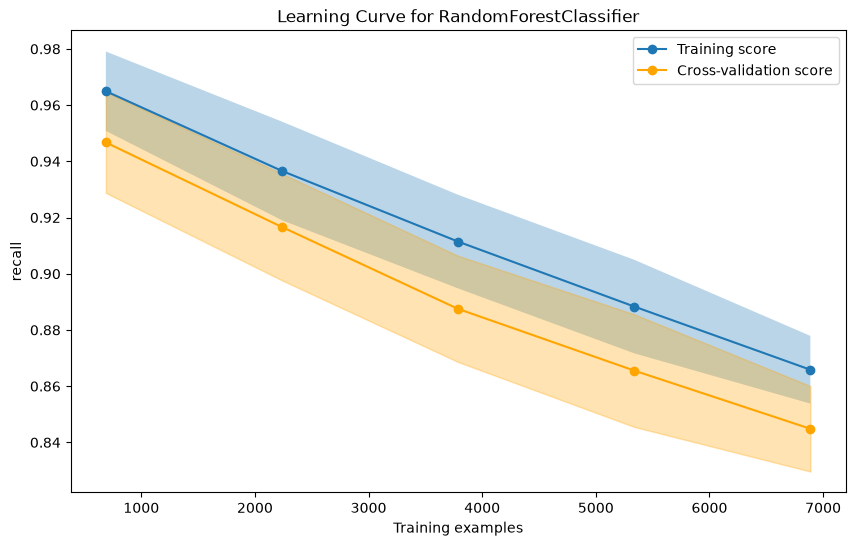

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [0.96494876 0.93657871 0.91143555 0.88833084 0.86584768]
Training Scores Std: [0.01412315 0.0175436  0.01665328 0.01664157 0.01204237]
Test Scores Mean: [0.94671982 0.91662197 0.88749264 0.865544   0.84484926]
Test Scores Std: [0.01795647 0.01897236 0.01888686 0.02003825 0.01520321]


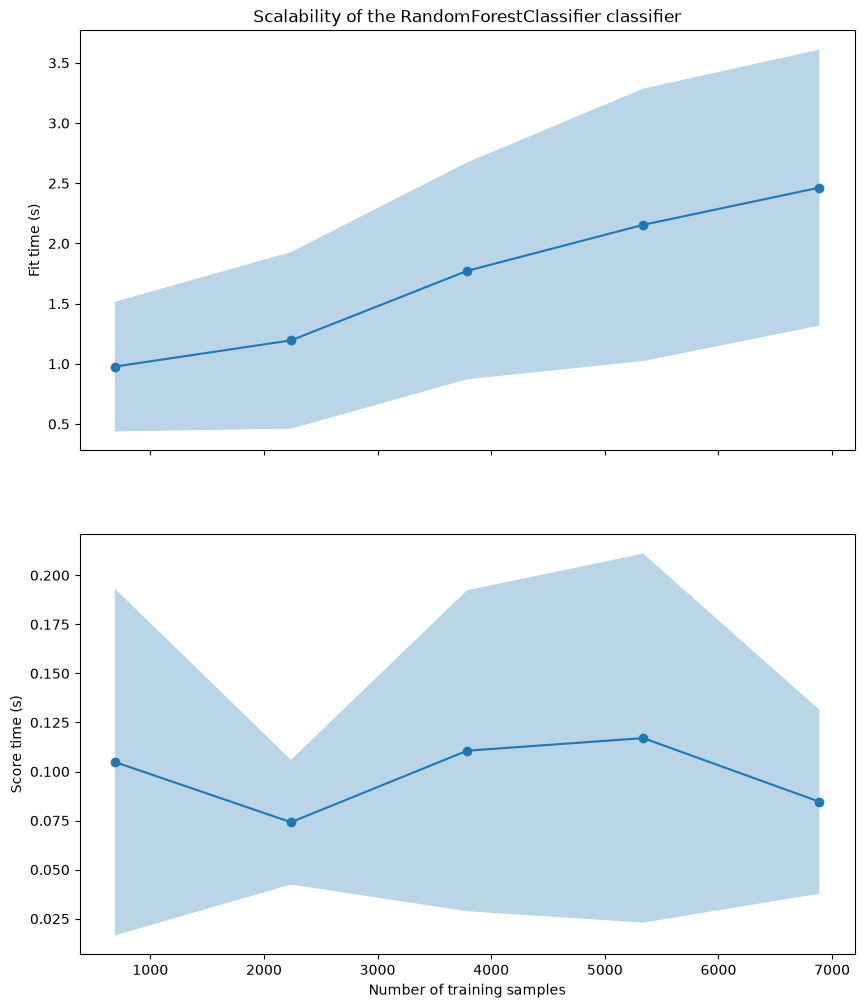

Fit Times Mean: [0.97705159 1.19471662 1.77224101 2.15482201 2.46358118]
Fit Times Std: [0.53846417 0.73382368 0.90080244 1.13158983 1.14691102]
Score Times Mean: [0.10485567 0.07417789 0.11060577 0.11702901 0.08461761]
Score Times Std: [0.08836748 0.03177054 0.08178836 0.09403032 0.04685582]


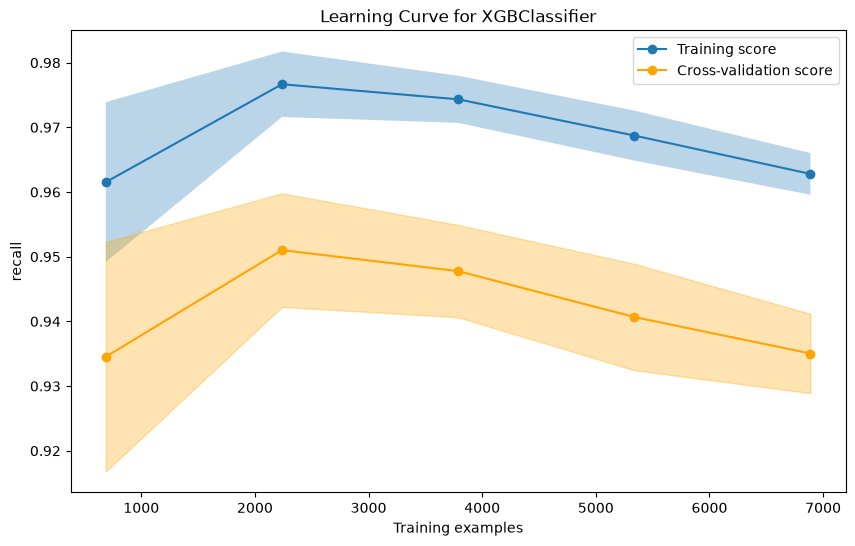

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [0.9615339  0.97667011 0.97434086 0.96873829 0.96280487]
Training Scores Std: [0.01236822 0.00506132 0.00364239 0.00386566 0.00322737]
Test Scores Mean: [0.93453817 0.9510225  0.94777358 0.94067782 0.93503476]
Test Scores Std: [0.01774814 0.00878041 0.00714286 0.00822645 0.00614064]


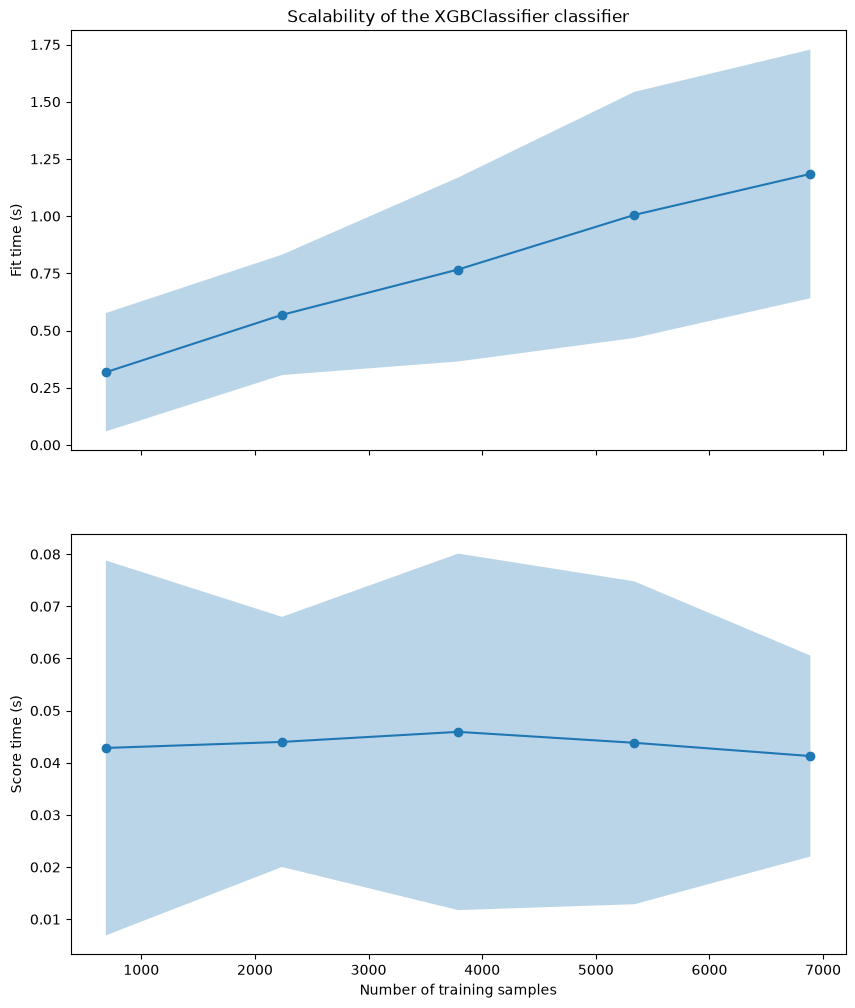

Fit Times Mean: [0.3176446  0.56838109 0.76663317 1.00512232 1.18455567]
Fit Times Std: [0.25861925 0.26316711 0.40195895 0.53779554 0.54332446]
Score Times Mean: [0.04284048 0.04399763 0.04592797 0.04382995 0.04128661]
Score Times Std: [0.03594637 0.02398155 0.03418288 0.03096058 0.01926716]


In [56]:
result_dict = {}
models = {
    "logistic": LogisticRegression(solver="liblinear",class_weight='balanced'),
    # class_weight='balanced' para manejar clases desbalanceadas
    "svc": LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False,class_weight='balanced'),
    "decision_tree": DecisionTreeClassifier(max_depth=5,min_samples_leaf=10,class_weight='balanced'),
    "random_forest": RandomForestClassifier(class_weight='balanced',n_estimators=150,max_depth=7,min_samples_leaf=5,max_features='sqrt'),
    "xgboost": XGBClassifier(eval_metric='logloss',scale_pos_weight=491 / 10090,n_estimators=200,max_depth=6,learning_rate=0.1,subsample=0.8,colsample_bytree=0.8)
    
}

data_params = {
    "name_of_y_col": 'Pago_atiempo',
    "names_of_x_cols": X_processed.columns.to_list(),
    "dataset": dataset_model
}
for model_name, model in models.items():
    result_dict[model_name] = build_model(model, data_params)

## Consolidar Resultados

In [66]:
records = []
for model_name, model_results in result_dict.items():
    for data_set, metrics in model_results.items():
        for metric_name, score in metrics.items():
            records.append({
                "Model": model_name,
                "Data Set": data_set,
                "Metric": metric_name,
                "Score": score
            })

results_df = pd.DataFrame(records)
print(results_df.to_string())

            Model Data Set     Metric     Score
0        logistic    train   accuracy  0.731010
1        logistic    train  precision  0.961279
2        logistic    train     recall  0.747714
3        logistic    train         f1  0.841152
4        logistic     test   accuracy  0.720390
5        logistic     test  precision  0.959417
6        logistic     test     recall  0.737689
7        logistic     test         f1  0.834068
8             svc    train   accuracy  0.587108
9             svc    train  precision  0.959091
10            svc    train     recall  0.591757
11            svc    train         f1  0.731921
12            svc     test   accuracy  0.578263
13            svc     test  precision  0.958300
14            svc     test     recall  0.582643
15            svc     test         f1  0.724682
16  decision_tree    train   accuracy  0.705343
17  decision_tree    train  precision  0.975966
18  decision_tree    train     recall  0.708084
19  decision_tree    train         f1  0

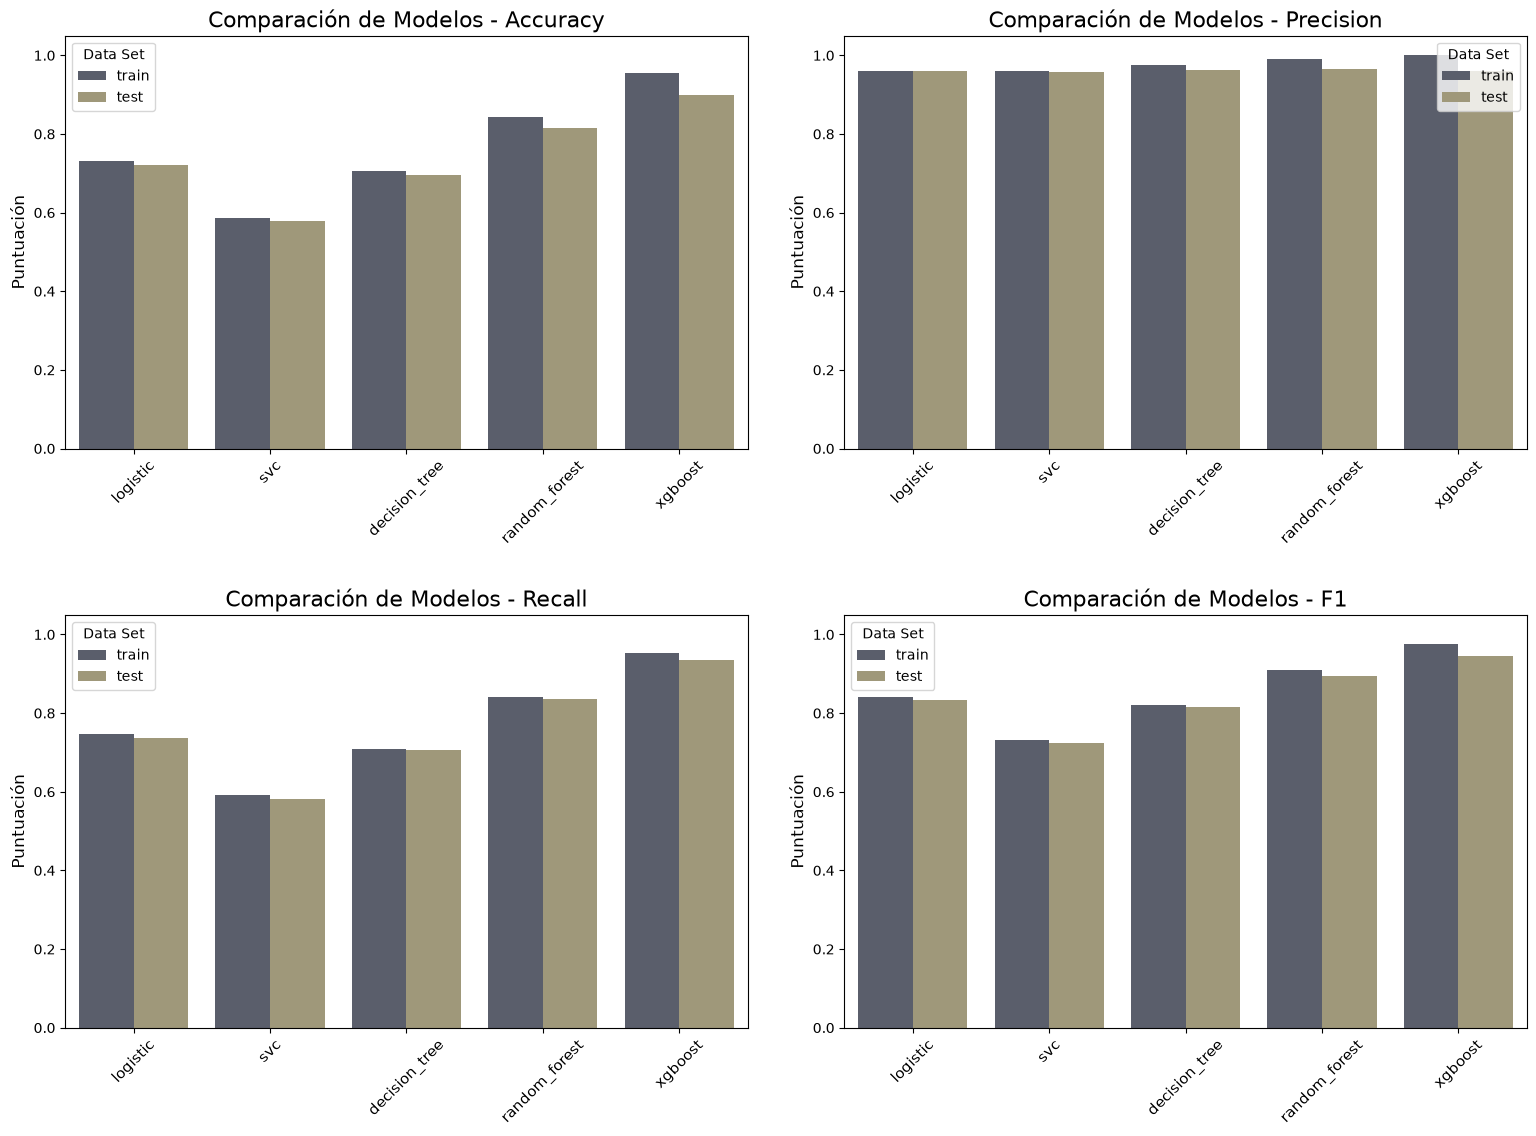

In [65]:
metrics_to_plot = results_df['Metric'].unique().tolist()

# Crear una figura con una cuadrícula de subplots (3 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Aplanar la matriz de ejes para iterar fácilmente

# Iterar sobre cada métrica y crear un gráfico para ella
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    # Filtrar el DataFrame para la métrica actual
    metric_df = results_df[results_df["Metric"] == metric]
    
    # Crear el gráfico de barras agrupado
    sns.barplot(data=metric_df, x="Model", y="Score", hue="Data Set", ax=ax, palette="cividis")
    
    ax.set_title(f'Comparación de Modelos - {metric.replace("_", " ").title()}', fontsize=16)
    ax.set_ylabel("Puntuación", fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    
    # Ajustar el límite del eje Y para que la comparación sea justa
    # Para ROC AUC, la escala es de 0.45 a 1.05 para ver mejor las diferencias
    if metric == 'roc_auc':
        ax.set_ylim(0.45, 1.05)
    elif metric == 'casosNoPagoAtiempo':
        max_no_pago = results_df[results_df["Metric"] == "casosNoPagoAtiempo"]["Score"].max()
        ax.set_ylim(0, max_no_pago + 5)
    else:
        ax.set_ylim(0, 1.05)

# Ocultar el último subplot que no se usa
if len(metrics_to_plot) < len(axes):
    axes[-1].set_visible(False)

# Ajustar el diseño para que no se superpongan los títulos
plt.tight_layout(pad=3.0)
plt.show()

El modelo XGBoost será  usado porque ofrece las mejores métricas de precisión, F1-Score y ROC AUC, lo que garantiza predicciones de alta calidad. Además, muestra un sobreajuste mucho más controlado que otros modelos complejos como Random Forest, lo que lo hace más fiable en un entorno de producción. Adicionalmente, es significativamente más rápido de entrenar que Random Forest, lo que permite un desarrollo más ágil y su aplicación a conjuntos de datos más grandes sin problemas. Como xgboost no es sensible al escalado de datos, se entrenará con los datos originales del dataframe